In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import interpolate
import os

# ── Paths ──────────────────────────────────────────────────────────────────────
ref_path    = ("/glade/campaign/cesm/development/liwg/forAdvik/"
               "CISM3_initialization_AIS_08000.b_h_s_interp_median.m1for0bed.2025-03-03.nc")
edc_path    = "/glade/u/home/advike/edc3deuttemp2007.txt"
forcing_dir = "/glade/derecho/scratch/advike/CESM_Regrid/"

Age range: -50 to 801662 yr BP
Temp range: -10.58 to 5.46 °C


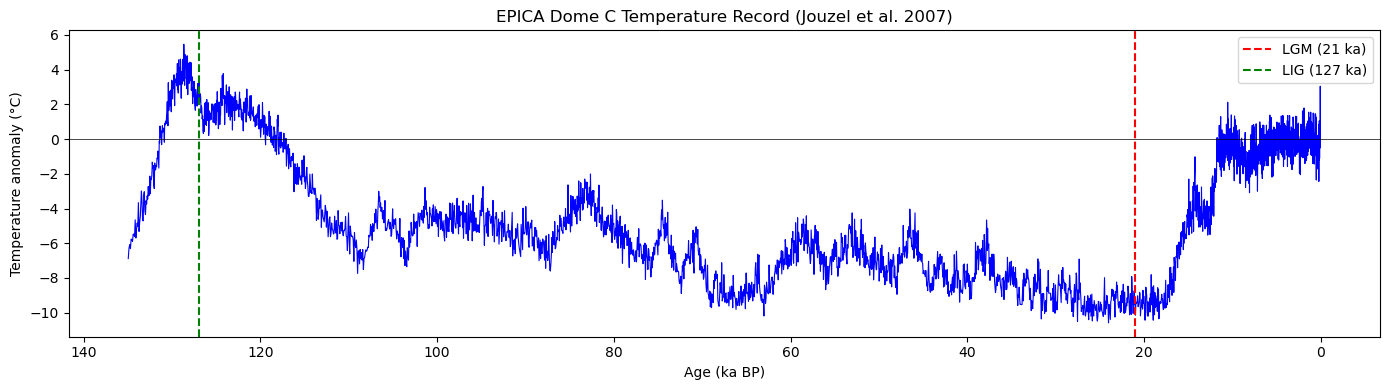

In [2]:
edc = pd.read_csv(edc_path,
                  skiprows=92,
                  sep='\s+',
                  names=["bag", "depth", "age", "dD", "temp"])
edc = edc.apply(pd.to_numeric, errors='coerce').dropna(subset=["age"])

print(f"Age range: {edc['age'].min():.0f} to {edc['age'].max():.0f} yr BP")
print(f"Temp range: {edc['temp'].min():.2f} to {edc['temp'].max():.2f} °C")

edc_plot = edc[(edc['age'] >= 0) & (edc['age'] <= 135000)].dropna(subset=['temp'])
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(edc_plot['age'] / 1000, edc_plot['temp'], 'b-', linewidth=0.8)
ax.axvline(x=21,  color='r', linestyle='--', label='LGM (21 ka)')
ax.axvline(x=127, color='g', linestyle='--', label='LIG (127 ka)')
ax.axhline(y=0,   color='k', linestyle='-',  linewidth=0.5)
ax.set_xlabel('Age (ka BP)')
ax.set_ylabel('Temperature anomaly (°C)')
ax.set_title('EPICA Dome C Temperature Record (Jouzel et al. 2007)')
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.show()

EDC anchor temperatures:
  PD:  -0.15 °C
  LGM: -9.39 °C
  LIG: 2.28 °C

Time slices: 255 steps, 0 to 127000 yr BP
Max weight sum deviation from 1: 0.00e+00


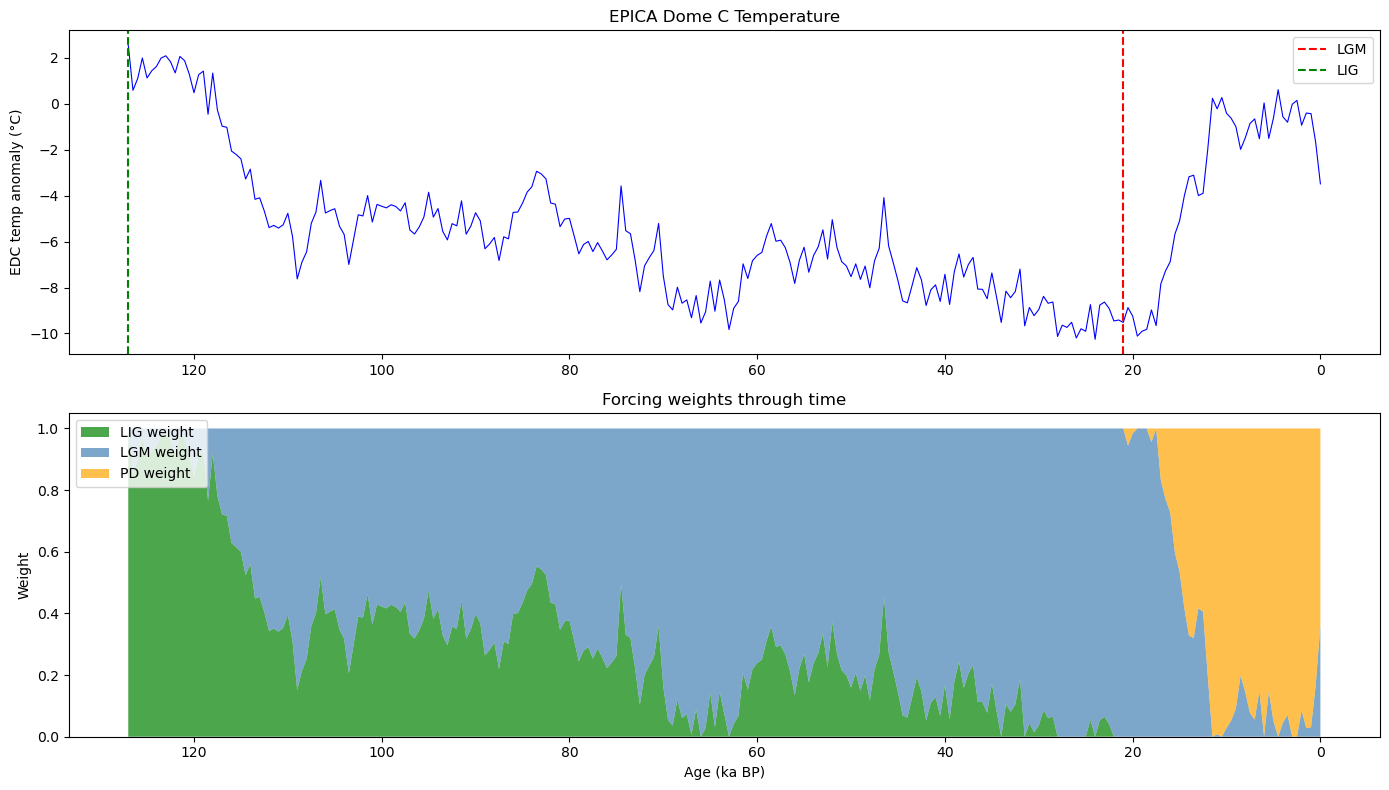

In [3]:
edc_valid = edc[(edc['age'] >= 0) & (edc['age'] <= 130000)].dropna(subset=['temp'])

temp_PD  = edc[(edc['age'] >= 0)      & (edc['age'] <= 1000)  ]['temp'].mean()
temp_LGM = edc[(edc['age'] >= 19000)  & (edc['age'] <= 23000) ]['temp'].mean()
temp_LIG = edc[(edc['age'] >= 120000) & (edc['age'] <= 130000)]['temp'].mean()

print(f"EDC anchor temperatures:")
print(f"  PD:  {temp_PD:.2f} °C")
print(f"  LGM: {temp_LGM:.2f} °C")
print(f"  LIG: {temp_LIG:.2f} °C")

# 500-year time slices from 127ka to 0
time_slices = np.arange(127000, -500, -500)
print(f"\nTime slices: {len(time_slices)} steps, {time_slices[-1]} to {time_slices[0]} yr BP")

# Interpolate EDC onto time slices
edc_interp    = interpolate.interp1d(edc_valid['age'], edc_valid['temp'],
                                      kind='linear', bounds_error=False,
                                      fill_value='extrapolate')
edc_on_slices = edc_interp(time_slices)

# Compute weights
weights_LGM = np.zeros(len(time_slices))
weights_LIG = np.zeros(len(time_slices))
weights_PD  = np.zeros(len(time_slices))

for i, (age, temp) in enumerate(zip(time_slices, edc_on_slices)):
    if age >= 21000:
        alpha          = np.clip((temp - temp_LIG) / (temp_LGM - temp_LIG), 0, 1)
        weights_LGM[i] = alpha
        weights_LIG[i] = 1 - alpha
    else:
        alpha          = np.clip((temp - temp_LGM) / (temp_PD - temp_LGM), 0, 1)
        weights_PD[i]  = alpha
        weights_LGM[i] = 1 - alpha

print(f"Max weight sum deviation from 1: {np.abs(weights_LGM + weights_LIG + weights_PD - 1).max():.2e}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(time_slices/1000, edc_on_slices, 'b-', linewidth=0.8)
axes[0].axvline(x=21,  color='r', linestyle='--', label='LGM')
axes[0].axvline(x=127, color='g', linestyle='--', label='LIG')
axes[0].set_ylabel('EDC temp anomaly (°C)')
axes[0].set_title('EPICA Dome C Temperature')
axes[0].legend()
axes[0].invert_xaxis()

axes[1].stackplot(time_slices/1000, weights_LIG, weights_LGM, weights_PD,
                  labels=['LIG weight', 'LGM weight', 'PD weight'],
                  colors=['green', 'steelblue', 'orange'], alpha=0.7)
axes[1].set_xlabel('Age (ka BP)')
axes[1].set_ylabel('Weight')
axes[1].set_title('Forcing weights through time')
axes[1].legend(loc='upper left')
axes[1].invert_xaxis()
plt.tight_layout()
plt.show()

In [4]:
def clean(arr):
    """Mask large negative and positive fill values."""
    a = arr.astype("float64")
    return np.where((a <= -9999.) | (a > 1e10), np.nan, a)

ds_pd       = xr.open_dataset(ref_path, decode_cf=False)
ds_lgm_pdd  = xr.open_dataset(forcing_dir + "CISM3_forcing_AIS_08000.lgm21ka.pdd.nc",     decode_cf=False)
ds_lgm_anom = xr.open_dataset(forcing_dir + "CISM3_forcing_AIS_08000.lgm21ka.anomaly.nc",  decode_cf=False)
ds_lig_pdd  = xr.open_dataset(forcing_dir + "CISM3_forcing_AIS_08000.lig127ka.pdd.nc",     decode_cf=False)
ds_lig_anom = xr.open_dataset(forcing_dir + "CISM3_forcing_AIS_08000.lig127ka.anomaly.nc", decode_cf=False)

ds_ipi_trefht = xr.open_dataset(forcing_dir + "ipi_trefht_on_cism8km.nc")
ds_lgm_trefht = xr.open_dataset(forcing_dir + "lgm21ka_trefht_on_cism8km.nc")
ds_lig_trefht = xr.open_dataset(forcing_dir + "lig127ka_trefht_on_cism8km.nc")

pd_artm      = clean(ds_pd["artm"].isel(time=0).values)
pd_smb       = clean(ds_pd["smb"].isel(time=0).values)
pd_tf        = clean(ds_pd["thermal_forcing"].isel(time=0).values)   # (zocn, y1, x1)

lgm_artm     = clean(ds_lgm_pdd["artm"].isel(time=0).values)
lgm_smb_pdd  = clean(ds_lgm_pdd["smb"].isel(time=0).values)
lgm_smb_anom = clean(ds_lgm_anom["smb"].isel(time=0).values)
lgm_tf       = clean(ds_lgm_pdd["thermal_forcing"].isel(time=0).values)

lig_artm     = clean(ds_lig_pdd["artm"].isel(time=0).values)
lig_smb_pdd  = clean(ds_lig_pdd["smb"].isel(time=0).values)
lig_smb_anom = clean(ds_lig_anom["smb"].isel(time=0).values)
lig_tf       = clean(ds_lig_pdd["thermal_forcing"].isel(time=0).values)

pd_trefht    = ds_ipi_trefht["trefht"].values.astype("float64")
lgm_trefht   = ds_lgm_trefht["trefht"].values.astype("float64")
lig_trefht   = ds_lig_trefht["trefht"].values.astype("float64")

lon2d = ds_pd["Lon1"].isel(time=0).values
lat2d = ds_pd["Lat1"].isel(time=0).values

print("End members loaded:")
print(f"  artm    PD: {np.nanmean(pd_artm):.1f}°   LGM: {np.nanmean(lgm_artm):.1f}°   LIG: {np.nanmean(lig_artm):.1f}°C")
print(f"  trefht  PD: {np.nanmean(pd_trefht):.1f}°  LGM: {np.nanmean(lgm_trefht):.1f}°  LIG: {np.nanmean(lig_trefht):.1f}°C")
print(f"  smb_pdd PD: {np.nanmean(pd_smb):.1f}  LGM: {np.nanmean(lgm_smb_pdd):.1f}  LIG: {np.nanmean(lig_smb_pdd):.1f} mm/yr")
print(f"  smb_ano PD: {np.nanmean(pd_smb):.1f}  LGM: {np.nanmean(lgm_smb_anom):.1f}  LIG: {np.nanmean(lig_smb_anom):.1f} mm/yr")
print(f"  tf      PD: {np.nanmean(pd_tf):.2f}°  LGM: {np.nanmean(lgm_tf):.2f}°  LIG: {np.nanmean(lig_tf):.2f}°C")

End members loaded:
  artm    PD: -15.7°   LGM: -28.8°   LIG: -15.4°C
  trefht  PD: -18.2°  LGM: -30.6°  LIG: -17.9°C
  smb_pdd PD: 182.4  LGM: 73.7  LIG: 176.0 mm/yr
  smb_ano PD: 182.4  LGM: 75.3  LIG: 178.8 mm/yr
  tf      PD: 2.29°  LGM: -0.16°  LIG: 3.12°C


In [5]:
n_times = len(time_slices)
ny, nx  = pd_artm.shape
nz      = pd_tf.shape[0]

artm_out     = np.full((n_times, ny, nx),     np.nan, dtype="float32")
trefht_out   = np.full((n_times, ny, nx),     np.nan, dtype="float32")
smb_pdd_out  = np.full((n_times, ny, nx),     np.nan, dtype="float32")
smb_anom_out = np.full((n_times, ny, nx),     np.nan, dtype="float32")
tf_out       = np.full((n_times, nz, ny, nx), np.nan, dtype="float32")

for i in range(n_times):
    w_pd  = weights_PD[i]
    w_lgm = weights_LGM[i]
    w_lig = weights_LIG[i]

    artm_out[i]     = (w_pd  * np.nan_to_num(pd_artm,      nan=0.) +
                       w_lgm * np.nan_to_num(lgm_artm,     nan=0.) +
                       w_lig * np.nan_to_num(lig_artm,     nan=0.))
    trefht_out[i]   = (w_pd  * np.nan_to_num(pd_trefht,    nan=0.) +
                       w_lgm * np.nan_to_num(lgm_trefht,   nan=0.) +
                       w_lig * np.nan_to_num(lig_trefht,   nan=0.))
    smb_pdd_out[i]  = (w_pd  * np.nan_to_num(pd_smb,       nan=0.) +
                       w_lgm * np.nan_to_num(lgm_smb_pdd,  nan=0.) +
                       w_lig * np.nan_to_num(lig_smb_pdd,  nan=0.))
    smb_anom_out[i] = (w_pd  * np.nan_to_num(pd_smb,       nan=0.) +
                       w_lgm * np.nan_to_num(lgm_smb_anom, nan=0.) +
                       w_lig * np.nan_to_num(lig_smb_anom, nan=0.))
    tf_out[i]       = (w_pd  * np.nan_to_num(pd_tf,        nan=0.) +
                       w_lgm * np.nan_to_num(lgm_tf,        nan=0.) +
                       w_lig * np.nan_to_num(lig_tf,        nan=0.))

# Re-mask cells where all end members were NaN
all_nan_2d = np.isnan(pd_artm) & np.isnan(lgm_artm) & np.isnan(lig_artm)
all_nan_tf = (np.isnan(pd_tf).all(axis=0) & np.isnan(lgm_tf).all(axis=0)
              & np.isnan(lig_tf).all(axis=0))
for i in range(n_times):
    artm_out[i][all_nan_2d]     = np.nan
    trefht_out[i][all_nan_2d]   = np.nan
    smb_pdd_out[i][all_nan_2d]  = np.nan
    smb_anom_out[i][all_nan_2d] = np.nan
    tf_out[i][:, all_nan_tf]    = np.nan

print("Interpolation complete")
print(f"  artm:     {np.nanmin(artm_out):.1f} to {np.nanmax(artm_out):.1f} °C")
print(f"  trefht:   {np.nanmin(trefht_out):.1f} to {np.nanmax(trefht_out):.1f} °C")
print(f"  smb_pdd:  {np.nanmin(smb_pdd_out):.1f} to {np.nanmax(smb_pdd_out):.1f} mm/yr")
print(f"  smb_anom: {np.nanmin(smb_anom_out):.1f} to {np.nanmax(smb_anom_out):.1f} mm/yr")
print(f"  tf:       {np.nanmin(tf_out):.2f} to {np.nanmax(tf_out):.2f} °C")

Interpolation complete
  artm:     -65.3 to 8.0 °C
  trefht:   -64.5 to 7.2 °C
  smb_pdd:  -1588.7 to 4764.4 mm/yr
  smb_anom: -588.4 to 4764.4 mm/yr
  tf:       -1.27 to 9.51 °C


/glade/derecho/scratch/advike/tmp/ipykernel_42003/801569926.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


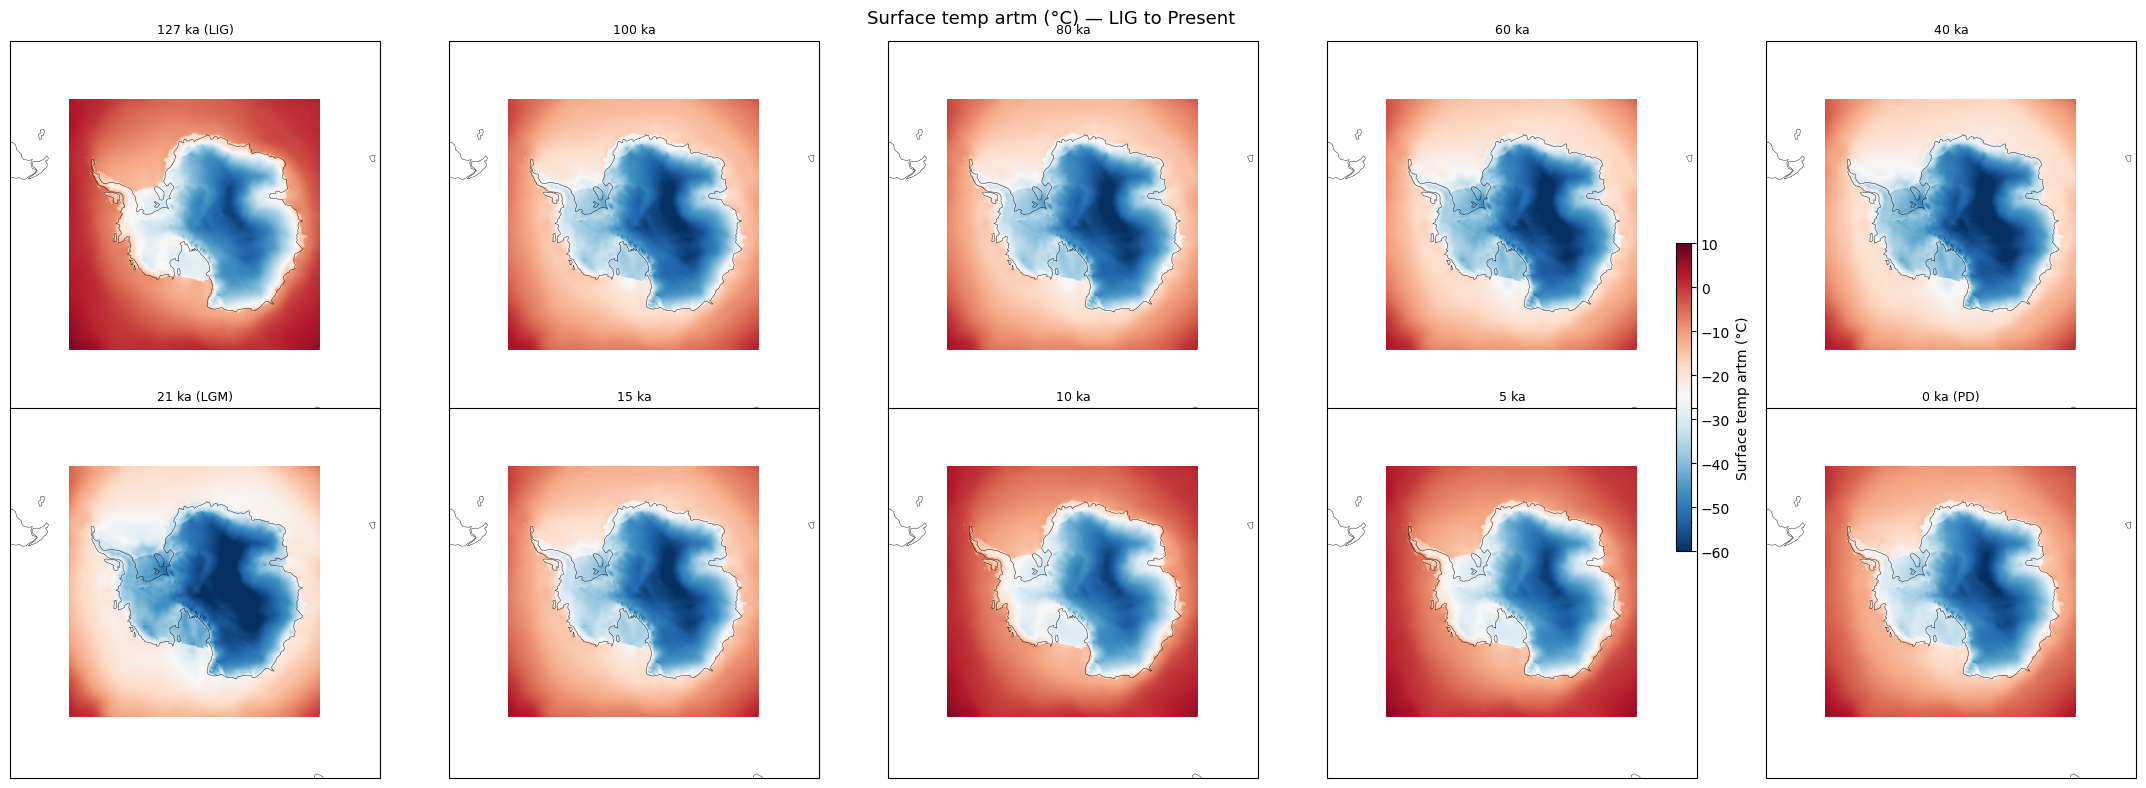

/glade/derecho/scratch/advike/tmp/ipykernel_42003/801569926.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


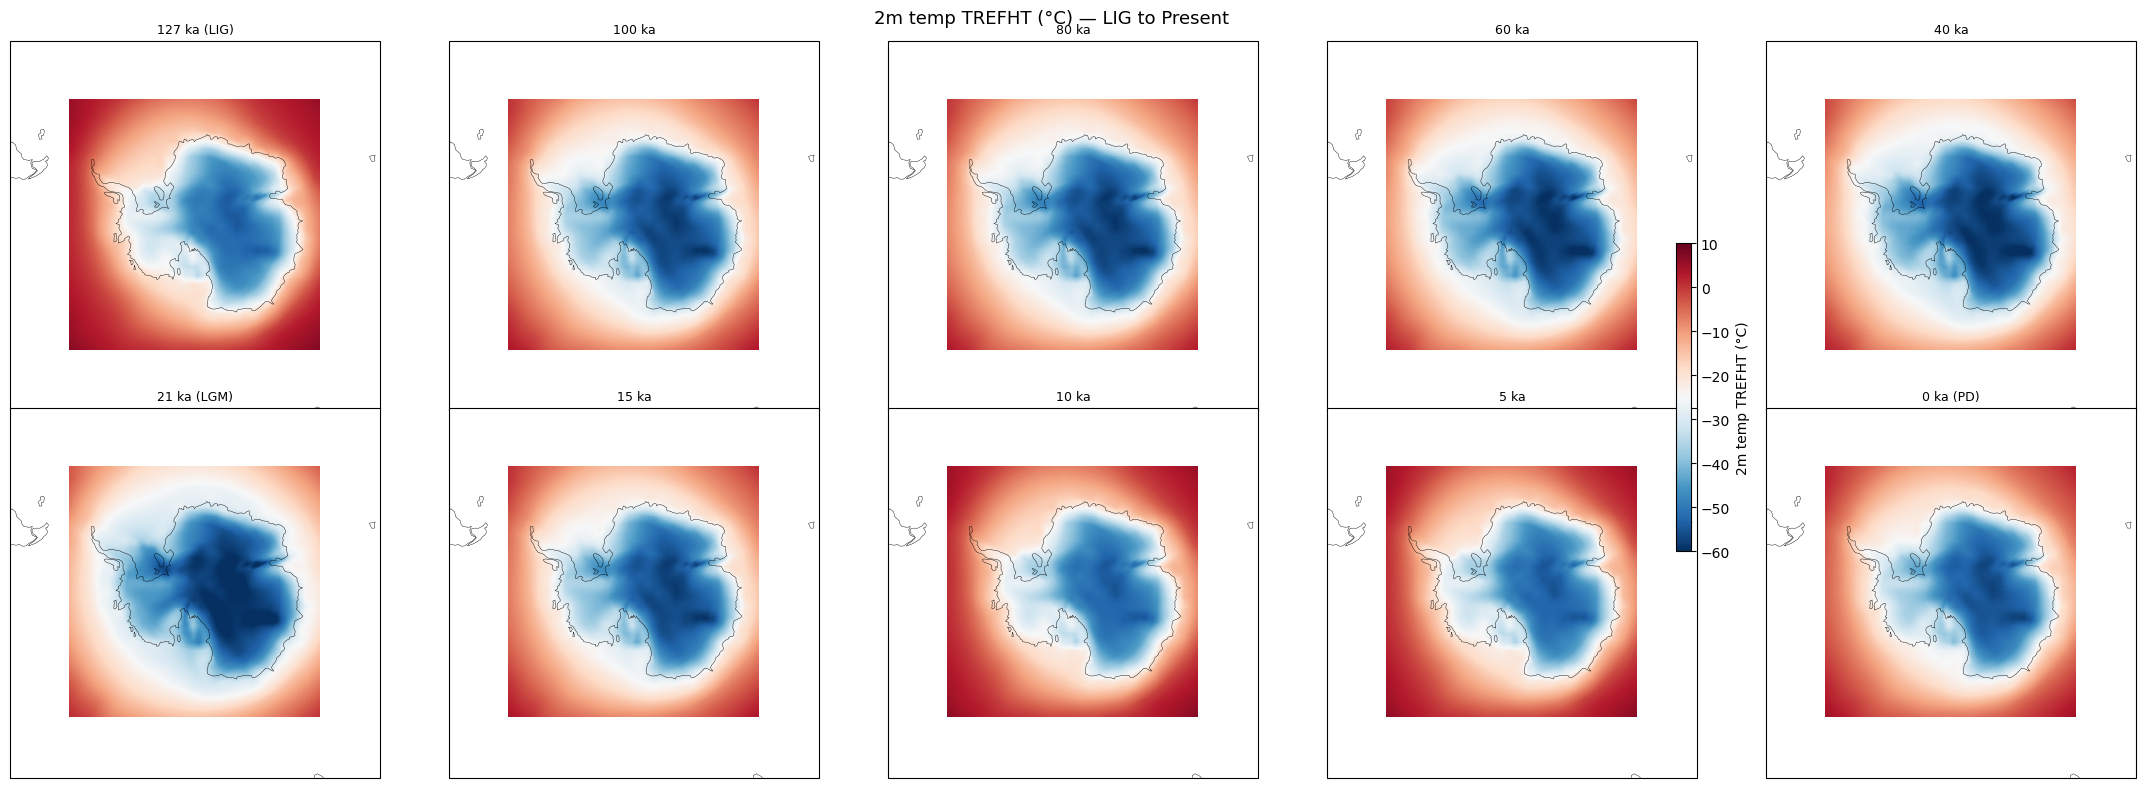

/glade/derecho/scratch/advike/tmp/ipykernel_42003/801569926.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


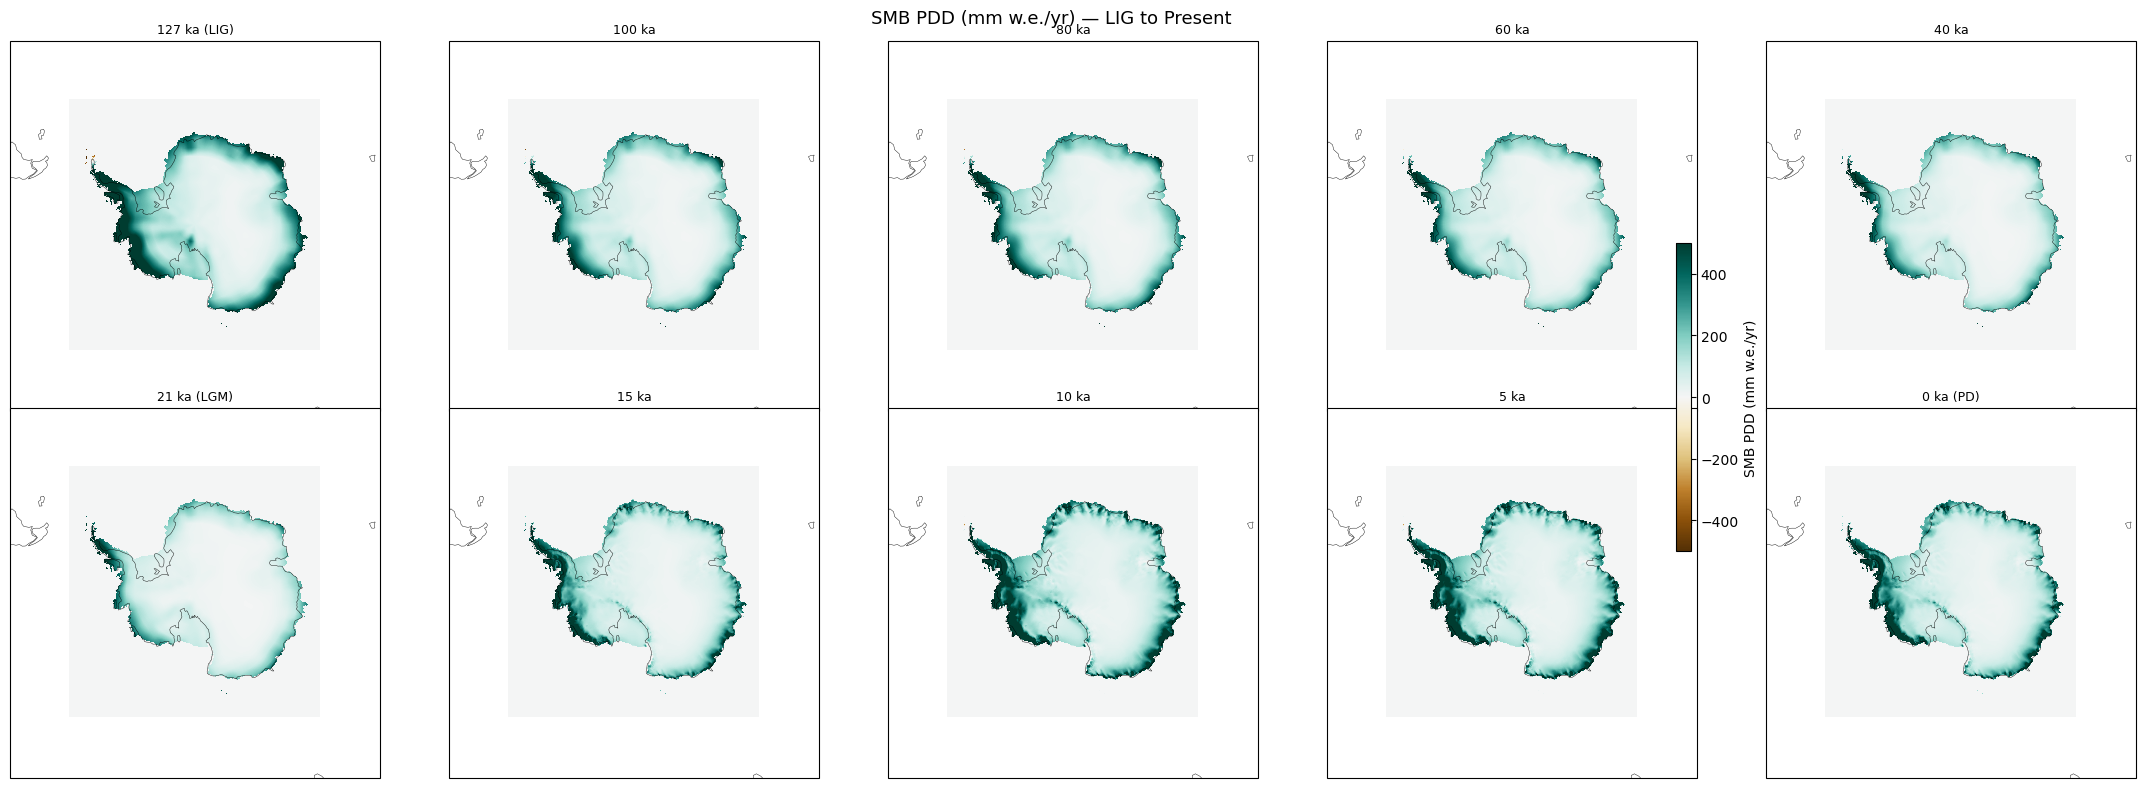

/glade/derecho/scratch/advike/tmp/ipykernel_42003/801569926.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


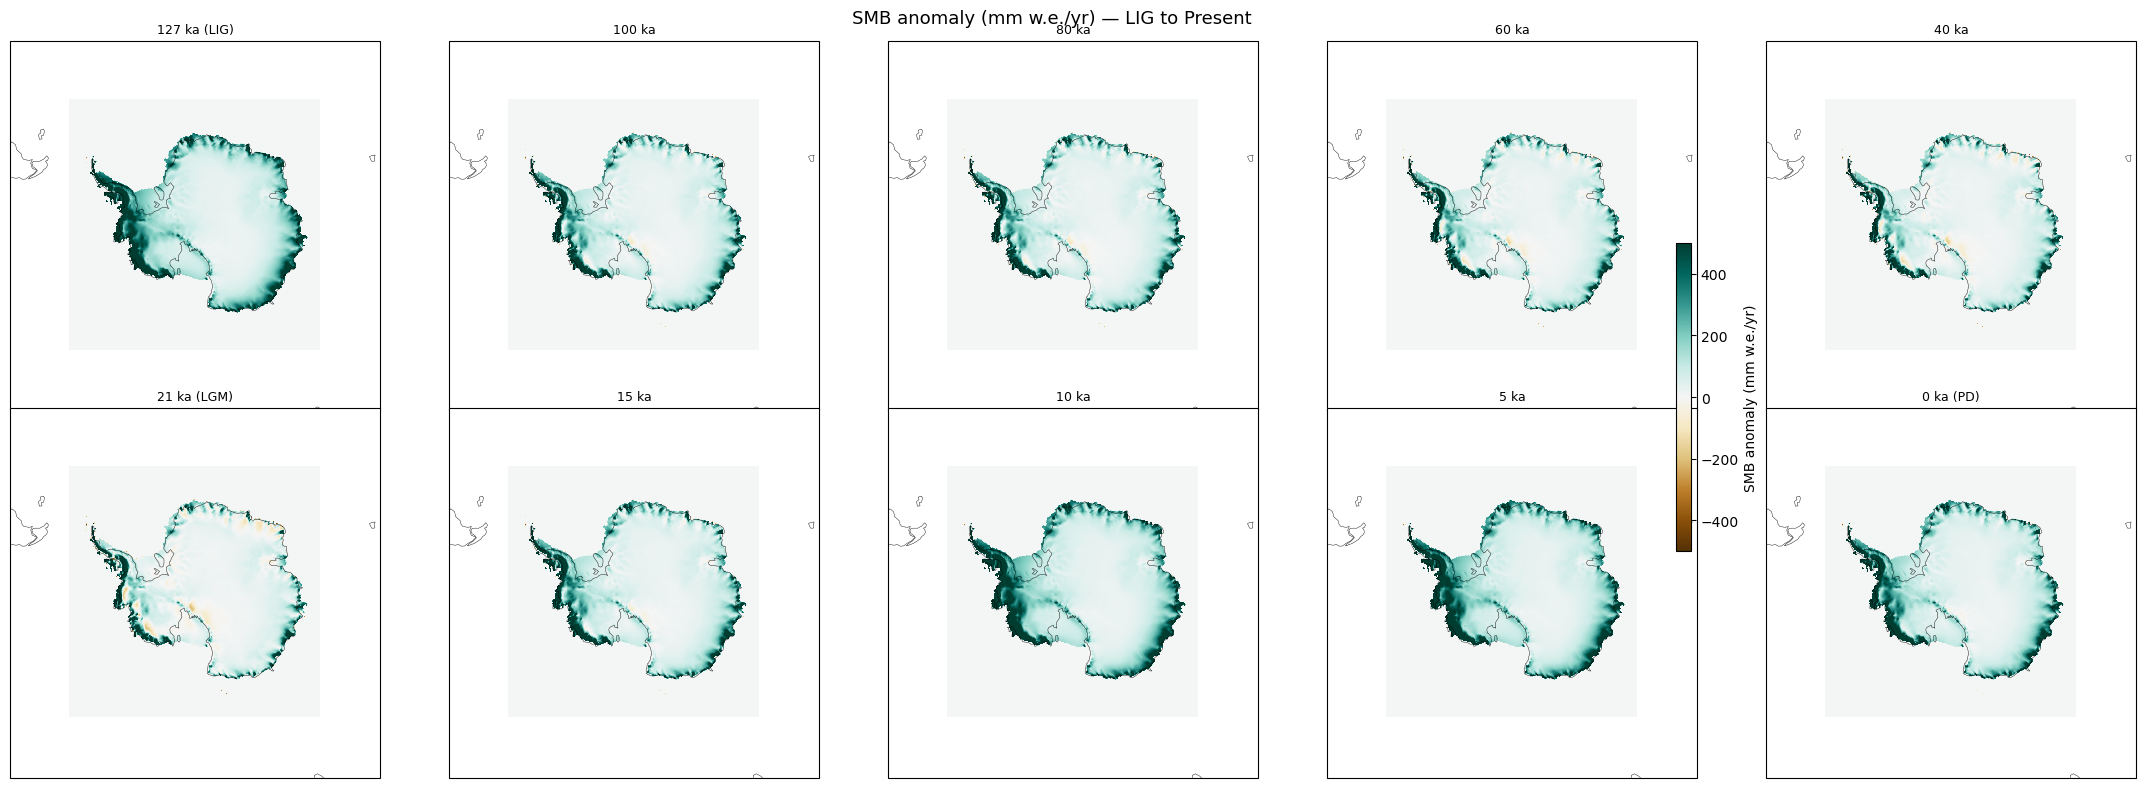

/glade/derecho/scratch/advike/tmp/ipykernel_42003/801569926.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


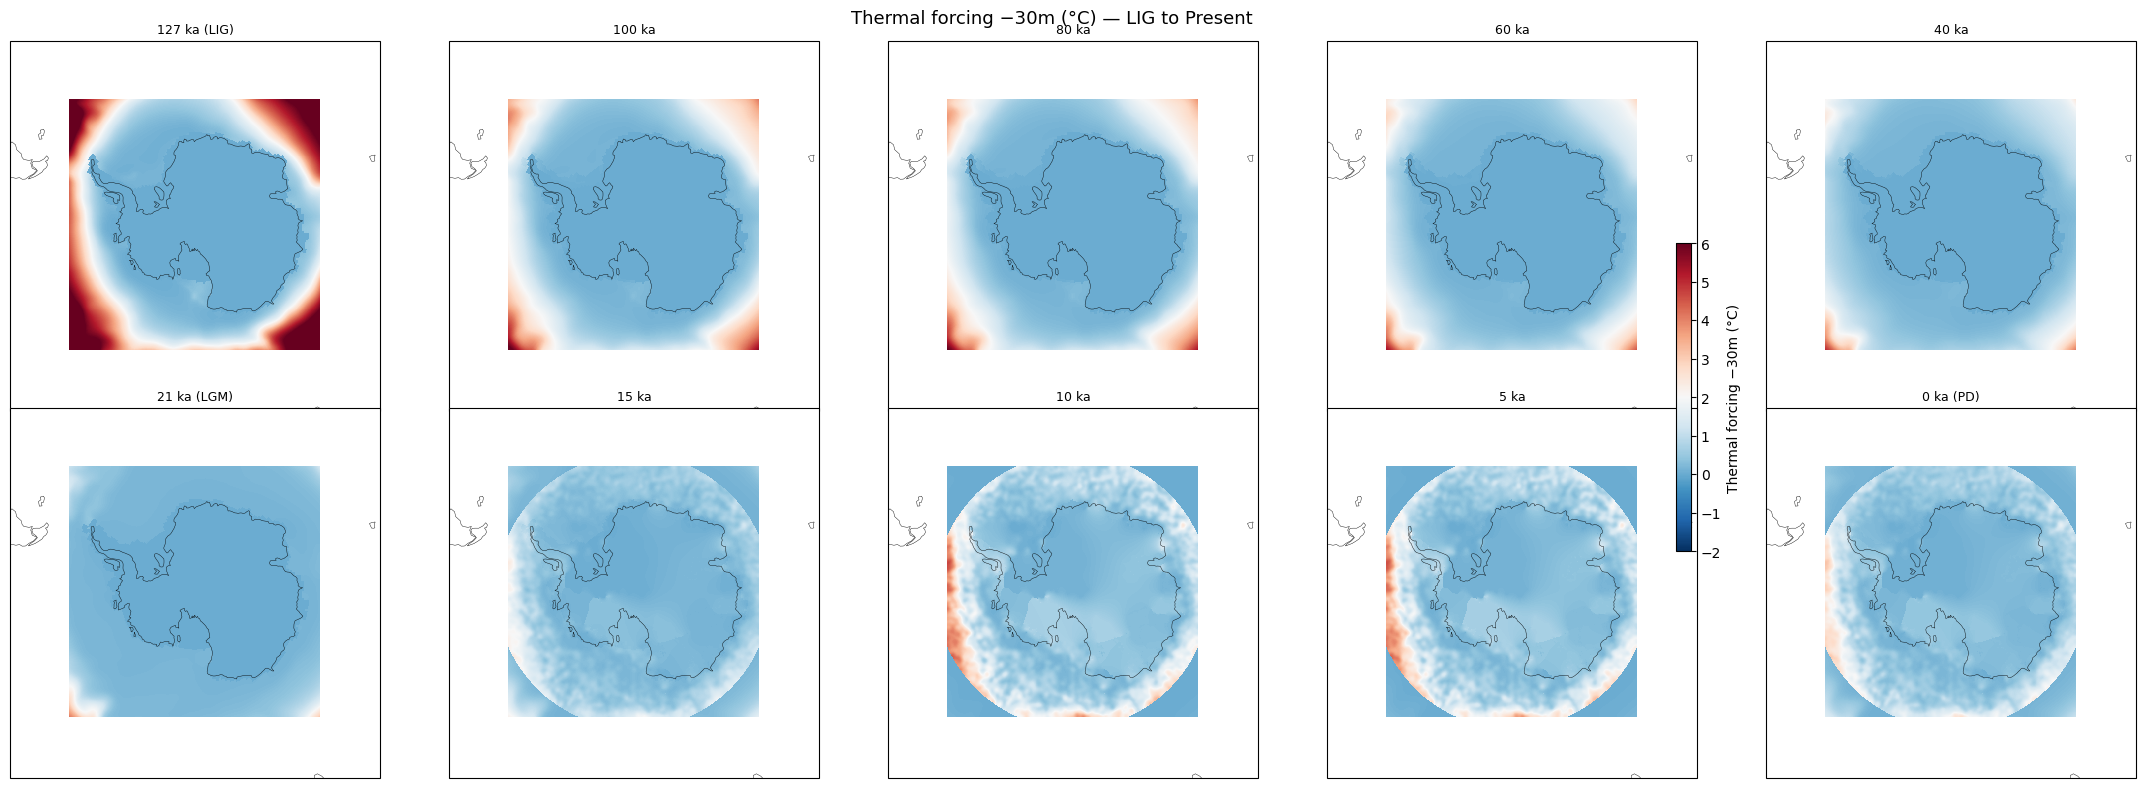

In [6]:
key_ages   = [127000, 100000, 80000, 60000, 40000, 21000, 15000, 10000, 5000, 0]
key_labels = ["127 ka (LIG)", "100 ka", "80 ka", "60 ka", "40 ka",
              "21 ka (LGM)", "15 ka", "10 ka", "5 ka", "0 ka (PD)"]
key_idx    = [np.argmin(np.abs(time_slices - a)) for a in key_ages]

plot_configs = [
    (artm_out,     "artm",     "RdBu_r", -60,  10,  "Surface temp artm (°C)"),
    (trefht_out,   "trefht",   "RdBu_r", -60,  10,  "2m temp TREFHT (°C)"),
    (smb_pdd_out,  "smb_pdd",  "BrBG",   -500, 500, "SMB PDD (mm w.e./yr)"),
    (smb_anom_out, "smb_anom", "BrBG",   -500, 500, "SMB anomaly (mm w.e./yr)"),
    (tf_out[:, 0], "tf_30m",   "RdBu_r", -2,   6,   "Thermal forcing −30m (°C)"),
]

for arr, varname, cmap, vmin, vmax, clabel in plot_configs:
    fig, axes = plt.subplots(2, 5, figsize=(22, 8),
                             subplot_kw={"projection": ccrs.SouthPolarStereo()})
    for ax, idx, label in zip(axes.flat, key_idx, key_labels):
        ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
        p = ax.pcolormesh(lon2d, lat2d, arr[idx],
                          transform=ccrs.PlateCarree(),
                          cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(label, fontsize=9)
    fig.colorbar(p, ax=axes.ravel().tolist(), label=clabel, shrink=0.5, pad=0.02)
    plt.suptitle(f"{clabel} — LIG to Present", fontsize=13)
    plt.tight_layout()
    plt.show()

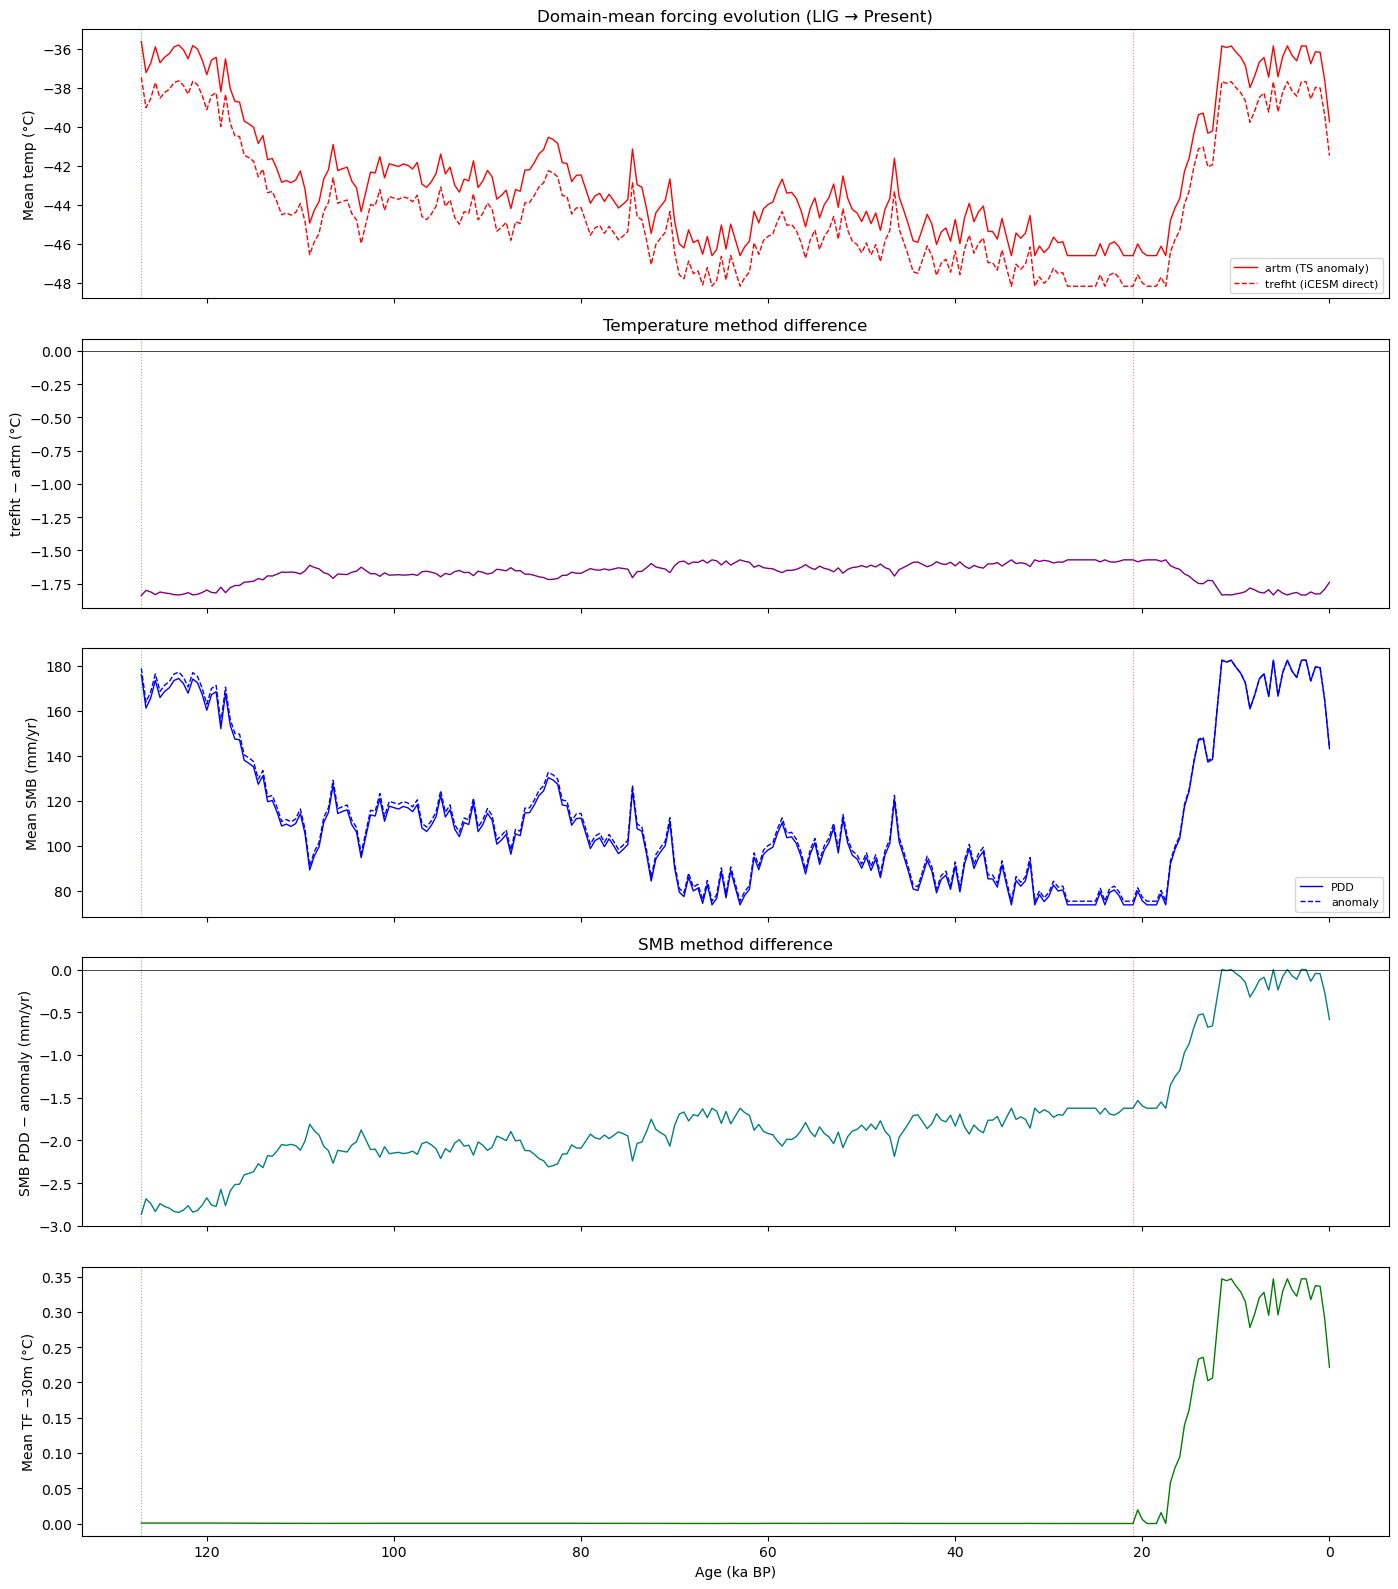

In [7]:
ice_mask_2d = np.isfinite(pd_smb)
ages_ka     = time_slices / 1000

def domain_mean(arr):
    return np.array([np.nanmean(arr[i][ice_mask_2d]) for i in range(n_times)])

tf_mean = np.array([np.nanmean(tf_out[i, 0][ice_mask_2d]) for i in range(n_times)])

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

axes[0].plot(ages_ka, domain_mean(artm_out),   'r-',  linewidth=1, label='artm (TS anomaly)')
axes[0].plot(ages_ka, domain_mean(trefht_out), 'r--', linewidth=1, label='trefht (iCESM direct)')
axes[0].set_ylabel("Mean temp (°C)")
axes[0].set_title("Domain-mean forcing evolution (LIG → Present)")
axes[0].legend(fontsize=8)

axes[1].plot(ages_ka, domain_mean(trefht_out) - domain_mean(artm_out), 'purple', linewidth=1)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_ylabel("trefht − artm (°C)")
axes[1].set_title("Temperature method difference")

axes[2].plot(ages_ka, domain_mean(smb_pdd_out),  'b-',  linewidth=1, label='PDD')
axes[2].plot(ages_ka, domain_mean(smb_anom_out), 'b--', linewidth=1, label='anomaly')
axes[2].set_ylabel("Mean SMB (mm/yr)")
axes[2].legend(fontsize=8)

axes[3].plot(ages_ka, domain_mean(smb_pdd_out) - domain_mean(smb_anom_out), 'teal', linewidth=1)
axes[3].axhline(0, color='k', linewidth=0.5)
axes[3].set_ylabel("SMB PDD − anomaly (mm/yr)")
axes[3].set_title("SMB method difference")

axes[4].plot(ages_ka, tf_mean, 'g-', linewidth=1)
axes[4].set_ylabel("Mean TF −30m (°C)")
axes[4].set_xlabel("Age (ka BP)")

for ax in axes:
    ax.invert_xaxis()
    ax.axvline(x=21,  color='r', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.axvline(x=127, color='g', linestyle=':', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()